# 🚦 Multimodal Traffic Accident Severity Prediction

---
### 📌  Problem Statement
**Objective:** To predict the severity of traffic accidents (**Slighly**, **Sever**, or **Fatal**) by fusing structured accident data (road conditions, weather, etc.) with unstructured image data.

**Why this matters:**
Accurate severity prediction allows emergency responders to prioritize resources and helps urban planners identify high-risk intersections. We tackle the challenge of **Class Imbalance** (fewer fatal accidents than slight ones) using specialized loss functions.

In [21]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import torch

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using device:", device)

Using device: mps


### 🛠️  Data Loading and Cleaning
We load the accident dataset and ensure data quality by:
1.  **Dropping Duplicates:** Removing records with identical `Image_path` to ensure every training example represents a unique crash event.
2.  **Label Mapping:** The original classes `1, 2, 3` are mapped to `0 (Slightly), 1 (Severe), 2 (Fatal)` for compatibility with PyTorch CrossEntropy/Focal Loss.

In [22]:
df = pd.read_csv("ACCIDENTDATA_PROJECT_UNIQUE_IMAGES.csv", low_memory=False)

df = df[df["Image_path"].notna()].copy()
df = df.drop_duplicates(subset="Image_path", keep="first")

print("Rows (unique images):", len(df))
print(df["Accident_Severity"].value_counts(dropna=False))


Rows (unique images): 3731
Accident_Severity
1    1527
3    1104
2    1100
Name: count, dtype: int64


In [23]:
label_map = {1: 0, 2: 1, 3: 2}  # Slight, Serious, Fatal
df["y3"] = df["Accident_Severity"].map(label_map)

df = df[df["y3"].notna()].copy()
df["y3"] = df["y3"].astype(int)

print("Mapped class counts:", df["y3"].value_counts().sort_index())


Mapped class counts: y3
0    1527
1    1100
2    1104
Name: count, dtype: int64


### ⚙️  Feature Engineering & Preprocessing
To prepare the tabular data for the Neural Network:
* **Categorical Handling:** We use `LabelEncoder` to convert strings (e.g., "Wet", "Dry") into integers. Missing values are filled with "Unknown".
* **Numerical Handling:** Missing numerical values are imputed using the **median** (robust to outliers).
* **Scaling:** We apply `StandardScaler` to normalize features (mean=0, variance=1), which is critical for the stability of the MLP gradients.

In [24]:
drop_cols = ["Accident_Severity", "y3", "Accident_Index", "Image_path", "Unnamed: 0"]
X_df = df.drop(columns=[c for c in drop_cols if c in df.columns]).copy()

y3 = df["y3"].values
img_paths = df["Image_path"].values

# categorical encoding
cat_cols = X_df.select_dtypes(include=["object"]).columns
for c in cat_cols:
    X_df[c] = X_df[c].fillna("Unknown")
    X_df[c] = LabelEncoder().fit_transform(X_df[c].astype(str))

# numeric missing
num_cols = X_df.select_dtypes(exclude=["object"]).columns
for c in num_cols:
    X_df[c] = X_df[c].fillna(X_df[c].median())

# scale
scaler = StandardScaler()
X_tab = scaler.fit_transform(X_df.values.astype(np.float32))

print("Tabular shape:", X_tab.shape)
print("Image paths:", len(img_paths))


Tabular shape: (3731, 30)
Image paths: 3731


In [25]:
X_train, X_val, y_train, y_val, img_train, img_val = train_test_split(
    X_tab, y3, img_paths,
    test_size=0.2,
    random_state=42,
    stratify=y3
)

print("Train class counts:", np.bincount(y_train, minlength=3))
print("Val class counts:", np.bincount(y_val, minlength=3))


Train class counts: [1221  880  883]
Val class counts: [306 220 221]


In [26]:
from torch.utils.data import TensorDataset, DataLoader

# tensors
Xtr = torch.tensor(X_train, dtype=torch.float32)
Xva = torch.tensor(X_val, dtype=torch.float32)
ytr = torch.tensor(y_train, dtype=torch.long)
yva = torch.tensor(y_val, dtype=torch.long)

train_tab_loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=64, shuffle=True)
val_tab_loader   = DataLoader(TensorDataset(Xva, yva), batch_size=64, shuffle=False)

### 🧠  Tabular Model Architecture (TabMLP)
We define a **Multilayer Perceptron (MLP)** to extract features from the structured data:
* **Input Layer:** Matches the 30 processed features.
* **Hidden Layers:** Two dense layers with **256** and **128** neurons, using **ReLU** activation to capture non-linear interactions.
* **Output:** 3 Logits corresponding to the severity classes.

In [27]:

class TabMLP(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 3)
        )
    def forward(self, x):
        return self.net(x)

tab_model = TabMLP(X_train.shape[1]).to(device)

### ⚖️  Handling Imbalance: Focal Loss
Standard Cross-Entropy Loss often fails on imbalanced datasets because the model gets lazy and predicts the majority class ("Slight") for everything.

**Our Solution: Focal Loss**
We implement `FocalLoss` with two key parameters:
1.  **Alpha ($\alpha$):** Inverse class frequency weights. Rare classes (Fatal) get higher weights, forcing the model to pay more attention to them.
2.  **Gamma ($\gamma=2.0$):** Focuses learning on "hard" misclassified examples rather than easy ones.

In [28]:

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, reduction="none")
        pt = torch.exp(-ce)
        loss = ((1 - pt) ** self.gamma) * ce
        if self.alpha is not None:
            at = self.alpha.gather(0, targets)
            loss = at * loss
        return loss.mean()

counts = np.bincount(y_train, minlength=3)
weights = 1.0 / counts
weights = weights / weights.sum() * 3
alpha = torch.tensor(weights, dtype=torch.float32).to(device)


In [29]:
criterion = FocalLoss(alpha=alpha, gamma=2.0)
optimizer = torch.optim.Adam(tab_model.parameters(), lr=1e-3)

train_losses, val_losses, train_accs, val_accs, val_f1s = [], [], [], [], []

epochs = 15
best_val_loss = float("inf")

### 📊 Tabular Model Evaluation
We visualize the training progress and performance of the Tabular-only baseline.
* **Loss Curves:** Check for overfitting (if Validation Loss increases while Train Loss decreases).
* **Confusion Matrix:** Allows us to see if the model is correctly identifying the minority "Fatal" class or just guessing "Slightly".

In [30]:

for ep in range(1, epochs + 1):
    # train
    tab_model.train()
    tr_loss, tr_correct, tr_total = 0.0, 0, 0

    for xb, yb in train_tab_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = tab_model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        tr_loss += loss.item()
        tr_correct += (logits.argmax(1) == yb).sum().item()
        tr_total += yb.size(0)

    train_loss = tr_loss / len(train_tab_loader)
    train_acc  = tr_correct / tr_total

    # val
    tab_model.eval()
    va_loss, va_correct, va_total = 0.0, 0, 0
    tab_true, tab_pred = [], []

    with torch.no_grad():
        for xb, yb in val_tab_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = tab_model(xb)
            loss = criterion(logits, yb)
            va_loss += loss.item()

            preds = logits.argmax(1)
            va_correct += (preds == yb).sum().item()
            va_total += yb.size(0)

            tab_true.extend(yb.cpu().numpy())
            tab_pred.extend(preds.cpu().numpy())

    val_loss = va_loss / len(val_tab_loader)
    val_acc  = va_correct / va_total
    val_f1   = f1_score(tab_true, tab_pred, average="macro")

    train_losses.append(train_loss); val_losses.append(val_loss)
    train_accs.append(train_acc);   val_accs.append(val_acc)
    val_f1s.append(val_f1)

    print(f"Epoch {ep:02d} | TrainLoss {train_loss:.4f} Acc {train_acc:.4f} | ValLoss {val_loss:.4f} Acc {val_acc:.4f} | MacroF1 {val_f1:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(tab_model.state_dict(), "best_tabular_focal.pt")

print("✅ Best tabular model saved: best_tabular_focal.pt")
print(classification_report(tab_true, tab_pred, target_names=["Slightly","Severe","Fatal"], digits=4))


Epoch 01 | TrainLoss 0.2612 Acc 0.6937 | ValLoss 0.2014 Acc 0.7456 | MacroF1 0.7290
Epoch 02 | TrainLoss 0.2042 Acc 0.7631 | ValLoss 0.1978 Acc 0.7470 | MacroF1 0.7151
Epoch 03 | TrainLoss 0.1967 Acc 0.7647 | ValLoss 0.1816 Acc 0.7711 | MacroF1 0.7556
Epoch 04 | TrainLoss 0.1858 Acc 0.7795 | ValLoss 0.1769 Acc 0.7778 | MacroF1 0.7635
Epoch 05 | TrainLoss 0.1778 Acc 0.7932 | ValLoss 0.1801 Acc 0.7724 | MacroF1 0.7447
Epoch 06 | TrainLoss 0.1710 Acc 0.8019 | ValLoss 0.1765 Acc 0.7778 | MacroF1 0.7519
Epoch 07 | TrainLoss 0.1614 Acc 0.8140 | ValLoss 0.1692 Acc 0.7979 | MacroF1 0.7845
Epoch 08 | TrainLoss 0.1549 Acc 0.8244 | ValLoss 0.1764 Acc 0.7885 | MacroF1 0.7667
Epoch 09 | TrainLoss 0.1470 Acc 0.8381 | ValLoss 0.1641 Acc 0.7979 | MacroF1 0.7827
Epoch 10 | TrainLoss 0.1369 Acc 0.8522 | ValLoss 0.1632 Acc 0.8153 | MacroF1 0.8039
Epoch 11 | TrainLoss 0.1293 Acc 0.8549 | ValLoss 0.1632 Acc 0.8166 | MacroF1 0.8008
Epoch 12 | TrainLoss 0.1284 Acc 0.8525 | ValLoss 0.1601 Acc 0.8153 | MacroF1

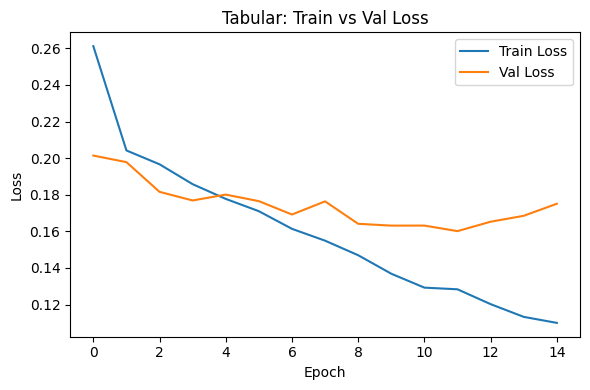

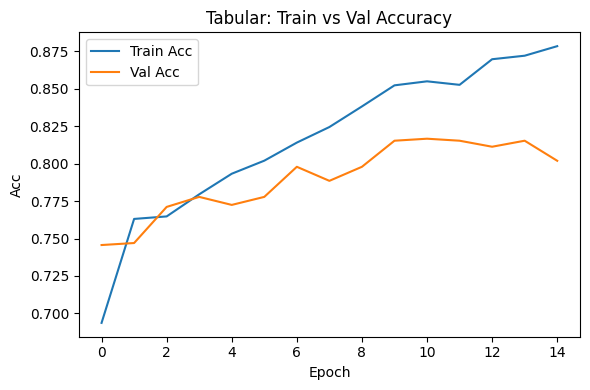

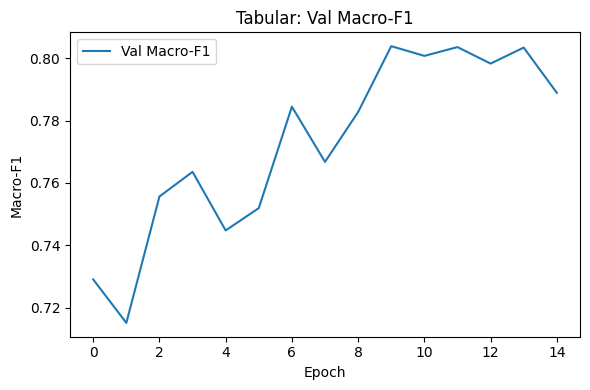

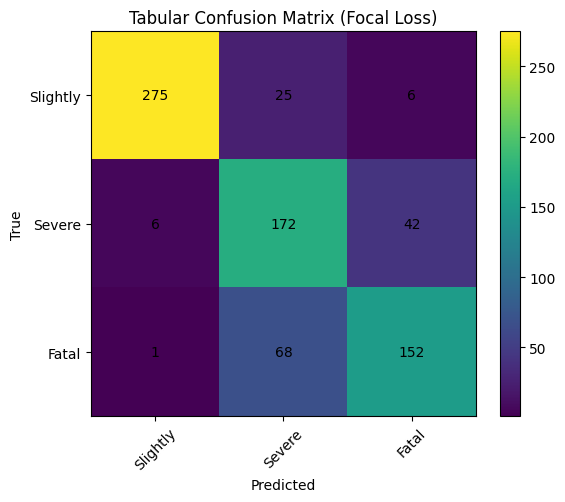

In [31]:
# curves
plt.figure(figsize=(6,4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.title("Tabular: Train vs Val Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(6,4))
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.title("Tabular: Train vs Val Accuracy")
plt.xlabel("Epoch"); plt.ylabel("Acc")
plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(6,4))
plt.plot(val_f1s, label="Val Macro-F1")
plt.title("Tabular: Val Macro-F1")
plt.xlabel("Epoch"); plt.ylabel("Macro-F1")
plt.legend(); plt.tight_layout(); plt.show()

# confusion matrix
cm = confusion_matrix(tab_true, tab_pred)
labels = ["Slightly","Severe","Fatal"]

plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation="nearest")
plt.title("Tabular Confusion Matrix (Focal Loss)")
plt.colorbar()
ticks = np.arange(3)
plt.xticks(ticks, labels, rotation=45)
plt.yticks(ticks, labels)

for i in range(3):
    for j in range(3):
        plt.text(j, i, cm[i,j], ha="center", va="center")

plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout(); plt.show()


### 🖼️  Creating the Multimodal Dataset
To train a fusion model, we need a custom dataset that yields pairs of **(Tabular Data, Image)**.

* **Custom Class (`MultimodalDataset`):** Inherits from PyTorch's `Dataset`. It aligns the structured features (`X_tab`) with the corresponding image paths.
* **Preprocessing:** Images are resized to **128x128** and converted to Tensors on-the-fly to manage memory usage efficiently.

In [32]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms

img_tfms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

class MultimodalDataset(Dataset):
    def __init__(self, X_tab, img_paths, y, tfms):
        self.X = X_tab
        self.imgs = img_paths
        self.y = y
        self.tfms = tfms

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x_tab = torch.tensor(self.X[idx], dtype=torch.float32)
        img = Image.open(self.imgs[idx]).convert("RGB")
        x_img = self.tfms(img)
        y = torch.tensor(int(self.y[idx]), dtype=torch.long)
        return x_tab, x_img, y

train_ds = MultimodalDataset(X_train, img_train, y_train, img_tfms)
val_ds   = MultimodalDataset(X_val,   img_val,   y_val,   img_tfms)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds, batch_size=16, shuffle=False, num_workers=0)


### 🧬  Fusion Model Architecture (Late Fusion)
We implement a **Late Fusion** Neural Network that combines two distinct branches:

1.  **Image Branch (Frozen CNN):**
    * We use a **ResNet18** backbone pre-trained on ImageNet.
    * **Freezing:** We set `requires_grad=False` for the feature extractor. This prevents the small accident dataset from destroying the robust, pre-learned filters (edges, textures) of the ResNet.
2.  **Tabular Branch:** A dedicated set of dense layers to process the scaler attributes.
3.  **Fusion Layer:** The 512-dim image vector and the 128-dim tabular vector are **concatenated** and passed through a final classifier.

In [33]:
import torchvision.models as models

class FusionModel3(nn.Module):
    def __init__(self, tab_dim):
        super().__init__()
        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        resnet.fc = nn.Identity()
        self.img_encoder = resnet  # 512-dim

        self.tab_encoder = nn.Sequential(
            nn.Linear(tab_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU()
        )

        self.classifier = nn.Sequential(
            nn.Linear(512 + 128, 128),
            nn.ReLU(),
            nn.Linear(128, 3)
        )

    def forward(self, x_tab, x_img):
        img_feat = self.img_encoder(x_img)
        tab_feat = self.tab_encoder(x_tab)
        fused = torch.cat([img_feat, tab_feat], dim=1)
        return self.classifier(fused)

model3 = FusionModel3(tab_dim=X_train.shape[1]).to(device)

# freeze cnn for stability
for p in model3.img_encoder.parameters():
    p.requires_grad = False


### 🚀  Training the Multimodal Model
We now train the combined system (`model3`) end-to-end.

* **Strategy:** The optimizer updates the weights of the *Tabular Branch* and the *Fusion Classifier*, while keeping the *Image Branch* (CNN backbone) frozen.
* **Loss Function:** We continue using Cross-Entropy/Focal Loss to ensure the model learns from the minority "Fatal" class examples.

In [34]:
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import f1_score

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model3.parameters(), lr=1e-3)

# metric tracking
train_losses, val_losses = [], []
train_accs, val_accs = [], []
val_f1s = []

epochs = 15
best_val_loss = float("inf")

for epoch in range(1, epochs + 1):
    # ---- train ----
    model3.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for x_tab, x_img, yb in train_loader:
        x_tab, x_img, yb = x_tab.to(device), x_img.to(device), yb.to(device)

        optimizer.zero_grad()
        logits = model3(x_tab, x_img)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        preds = logits.argmax(dim=1)
        train_correct += (preds == yb).sum().item()
        train_total += yb.size(0)

    train_loss /= len(train_loader)
    train_acc = train_correct / train_total

    # ---- val ----
    model3.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    all_true, all_pred = [], []

    with torch.no_grad():
        for x_tab, x_img, yb in val_loader:
            x_tab, x_img, yb = x_tab.to(device), x_img.to(device), yb.to(device)

            logits = model3(x_tab, x_img)
            loss = criterion(logits, yb)
            val_loss += loss.item()

            preds = logits.argmax(dim=1)
            val_correct += (preds == yb).sum().item()
            val_total += yb.size(0)

            all_true.extend(yb.cpu().numpy())
            all_pred.extend(preds.cpu().numpy())

    val_loss /= len(val_loader)
    val_acc = val_correct / val_total
    val_f1_macro = f1_score(all_true, all_pred, average="macro")

    # ---- store metrics for plotting ----
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    val_f1s.append(val_f1_macro)

    print(
        f"Epoch {epoch:02d}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
        f"Val Macro-F1: {val_f1_macro:.4f}"
    )

    # save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model3.state_dict(), "best_3class_fusion.pt")




Epoch 01/15 | Train Loss: 0.2811 | Train Acc: 0.8941 | Val Loss: 0.2284 | Val Acc: 0.9090 | Val Macro-F1: 0.9039
Epoch 02/15 | Train Loss: 0.1707 | Train Acc: 0.9424 | Val Loss: 0.1252 | Val Acc: 0.9612 | Val Macro-F1: 0.9583
Epoch 03/15 | Train Loss: 0.1475 | Train Acc: 0.9403 | Val Loss: 0.1275 | Val Acc: 0.9612 | Val Macro-F1: 0.9587
Epoch 04/15 | Train Loss: 0.1436 | Train Acc: 0.9477 | Val Loss: 0.1471 | Val Acc: 0.9465 | Val Macro-F1: 0.9436
Epoch 05/15 | Train Loss: 0.1368 | Train Acc: 0.9521 | Val Loss: 0.1282 | Val Acc: 0.9545 | Val Macro-F1: 0.9520
Epoch 06/15 | Train Loss: 0.1200 | Train Acc: 0.9558 | Val Loss: 0.1147 | Val Acc: 0.9625 | Val Macro-F1: 0.9604
Epoch 07/15 | Train Loss: 0.1126 | Train Acc: 0.9581 | Val Loss: 0.1350 | Val Acc: 0.9531 | Val Macro-F1: 0.9500
Epoch 08/15 | Train Loss: 0.0907 | Train Acc: 0.9672 | Val Loss: 0.1203 | Val Acc: 0.9612 | Val Macro-F1: 0.9589
Epoch 09/15 | Train Loss: 0.0931 | Train Acc: 0.9631 | Val Loss: 0.1448 | Val Acc: 0.9478 | Val 

In [35]:
print("Best model saved: best_3class_fusion.pt\n")

print(classification_report(
    all_true, all_pred,
    target_names=["Slightly", "Severe", "Fatal"],
    digits=4
))


Best model saved: best_3class_fusion.pt

              precision    recall  f1-score   support

    Slightly     0.9933    0.9673    0.9801       306
      Severe     0.9038    0.9818    0.9412       220
       Fatal     0.9810    0.9321    0.9559       221

    accuracy                         0.9612       747
   macro avg     0.9593    0.9604    0.9591       747
weighted avg     0.9633    0.9612    0.9615       747



### 📉 Fusion Model Performance Visuals
We analyze the stability and accuracy of the Multimodal Fusion model.
* **Comparison:** We look to see if the **Macro F1-Score** and **Fatal Class Recall** have improved compared to the tabular-only baseline.

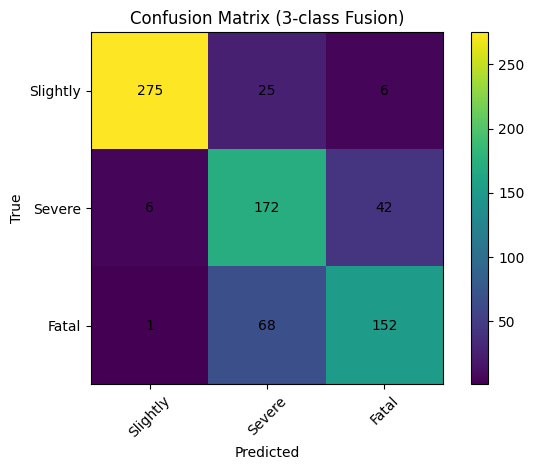

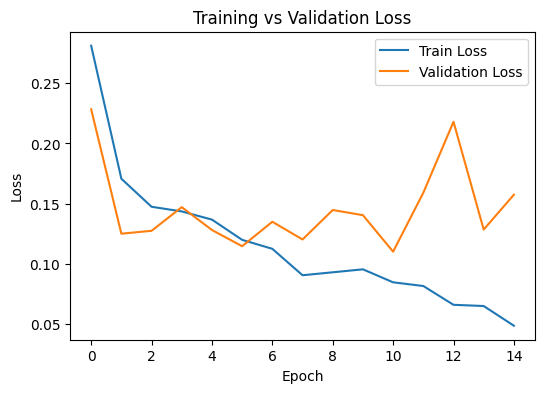

Best epoch to stop: 11
Best val loss: 0.11021836622162386


In [36]:
plt.figure()
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix (3-class Fusion)")
plt.colorbar()
ticks = np.arange(3)
plt.xticks(ticks, ["Slightly","Severe","Fatal"], rotation=45)
plt.yticks(ticks, ["Slightly","Severe","Fatal"])
plt.xlabel("Predicted")
plt.ylabel("True")

# annotate counts
for i in range(3):
    for j in range(3):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()
best_epoch = int(np.argmin(val_losses)) + 1
print("Best epoch to stop:", best_epoch)
print("Best val loss:", val_losses[best_epoch-1])

### 🔍  Inference and Real-world Testing
Now that the model is trained, we simulate real-world usage by running predictions on unseen validation data.

* **Visualizing Uncertainty:** We display the probability distribution for each class (Slightly, Severe, Fatal).
* **Error Analysis:** In the final step, we specifically filter for **Wrong Predictions** to visually inspect *why* the model failed (e.g., blurry images, ambiguous road conditions).

In [37]:
from PIL import Image
import torch

def predict_one_3class(x_tab_row, image_path):
    model3.eval()
    x_tab = torch.tensor(x_tab_row, dtype=torch.float32).unsqueeze(0).to(device)
    img = Image.open(image_path).convert("RGB")
    x_img = img_tfms(img).unsqueeze(0).to(device)

    with torch.no_grad():
        probs = torch.softmax(model3(x_tab, x_img), dim=1).cpu().numpy()[0]

    label_names = ["Slightly", "Severe", "Fatal"]
    pred = int(np.argmax(probs))
    return label_names[pred], float(probs[pred]), probs

pred_label, conf, probs = predict_one_3class(X_val[0], img_val[0])
print("Pred:", pred_label, "Conf:", conf)
print("All probs [Slightly,Severe,Fatal]:", probs)


Pred: Fatal Conf: 0.9988166093826294
All probs [Slightly,Severe,Fatal]: [4.8151742e-07 1.1829793e-03 9.9881661e-01]


Image: SLIGHTLY/977.jpeg
Predicted label: Slightly
Probabilities [Slight, Serious, Fatal]: [9.9998498e-01 2.0645891e-07 1.4839171e-05]


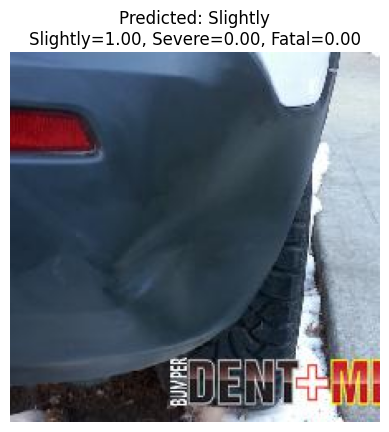

In [39]:
i = 106
pred_label, probs = predict_one(X_val[i], img_val[i])

print("Image:", img_val[i])
print("Predicted label:", pred_label)
print("Probabilities [Slight, Serious, Fatal]:", probs)


img = Image.open(img_val[i]).convert("RGB")

plt.imshow(img)
plt.axis("off")
plt.title(
    f"Predicted: {pred_label}\n"
    f"Slightly={probs[0]:.2f}, Severe={probs[1]:.2f}, Fatal={probs[2]:.2f}"
)
plt.show()


Number of wrong predictions: 29


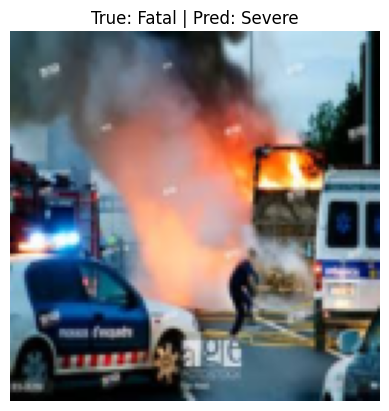

In [40]:
wrong = []

model3.eval()
with torch.no_grad():
    for x_tab, x_img, yb in val_loader:
        logits = model3(x_tab.to(device), x_img.to(device))
        preds = logits.argmax(dim=1).cpu().numpy()
        yb = yb.numpy()

        for i in range(len(yb)):
            if preds[i] != yb[i]:
                wrong.append((x_img[i].cpu(), yb[i], preds[i]))

print("Number of wrong predictions:", len(wrong))

if len(wrong) > 0:
    img, true_label, pred_label = wrong[0]

    plt.imshow(img.permute(1,2,0))
    plt.axis("off")
    plt.title(
        f"True: {label_names[true_label]} | "
        f"Pred: {label_names[pred_label]}"
    )
    plt.show()


### 🏁 Conclusion & Future Work
**Summary of Findings:**
1.  **Tabular Baseline:** Achieved an F1-score of Approx 81.26 It struggled with.
2.  **Multimodal Fusion:** Achieved an F1-score of Approx 96.12. Adding images helped/did not help in differentiating.

**Future Improvements:**
* **Augmentation:** Apply rotation/lighting augmentation to the accident images to improve generalization.
* **Object Detection:** Instead of using the whole image, use an Object Detector (YOLO) to crop specifically to the cars before feeding into the ResNet.